# Image Processing Notebook: Plot the H Cross-Section (from Transmission)


This notebook takes the processed transmission imagesand plot the H Cross-sections from specific ROIs

## Initial Settings

### Import Libraries

In [1]:
import sys
sys.path.append(r'..\01_Functions')
from step_functions import *
from dict_functions import *
from proc_functions import *
from img_functions import *
from cross_sections import *
%matplotlib inline
pd.set_option('display.max_rows', None)

### Provide Directories

#### Provide the directory for transmission images

In [2]:
# %load select_directory('src_dir')
src_dir = r"J:\700 Campaigns - internal\2021\PSI21_10NI_updated_framework\02_Transmission_results\exp103"

#### Provide the Spectra.txt file from any of the experiments. 
These are the neutron arrival times the MCP detected

In [3]:
# %load select_file('spectra_file')
spectra_file = r"J:\700 Campaigns - internal\2021\PSI21_10NI_updated_framework\00_Raw_sorted\exp102\005_temp_01_p10_batch01\exp102_031_Spectra.txt"

#### Provide the directory for saving results

In [4]:
# %load select_directory('dst_dir')
dst_dir = r"J:\700 Campaigns - internal\2021\PSI21_10NI_updated_framework\testing_CS_temp"

In [5]:
flight_path = 5.45

## Remove Casing 
read the directory and extract values from images

In [6]:
stack_dict = read_saved_dict (src_dir, proc_folder = ['003_temp_00_m23_batch03'])

Reading Images: 100%|████████████████████████████| 1/1 [00:00<00:00,  4.04it/s]


#### Extract an averaged image for each key
For each `proc_folder` (acquisition), an averaged image will be extracted

In [7]:
avg_imgs = []
for key, value in stack_dict.items():
    img =  avg_frames_dict (value, output_type = 'img', start_slice = 10, end_slice = 50)
    avg_imgs.append(img[0])

#### Select the Casing ROI
For simplicity handling the names, `ROIs_` before the name of the `proc_folder` is required

In [8]:
# %load select_multiple_rois(proc_folder[0], avg_images[0], cmap = 'flag')
#ROIs_003_temp_00_p20_batch03  = [[58, 296, 234, 54]]
ROIs_003_temp_00_m23_batch03  = [[112, 288, 188, 70]]

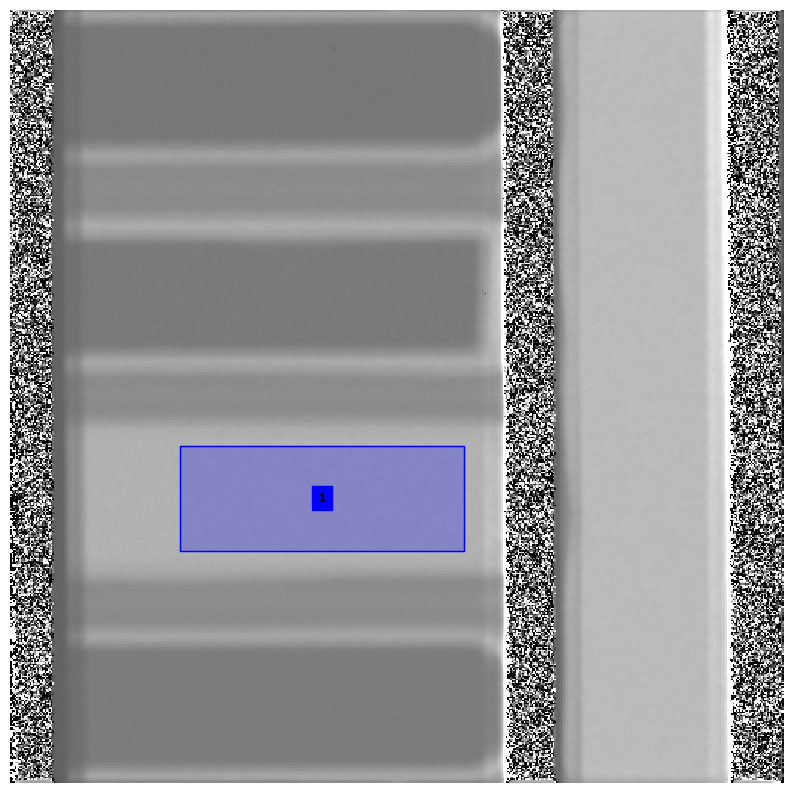

In [10]:
show_img(avg_imgs[0], dr = [(ROIs_003_temp_00_m23_batch03, 'blue')], cmap='gray')

#### Create a dictionary of the ROIs

In [11]:
rois_dict = {}
for name in stack_dict.keys():
    rois_name = 'ROIs_'+ name
    for rois in [rois_name]:
        rois_dict[rois] = eval(rois)

In [12]:
val_casing = get_roi_values (stack_dict, rois_dict, spectra_file, save_path = dst_dir, binning = 1, 
                                 flight_path = flight_path, start_slice = 0, end_slice='', name_xlsx = 'Roi_values_auto.xlsx', 
                                 save_results = False)

In [13]:
val_casing

,Wavelength [Å],Values_003_temp_00_m23_batch03_roi_1
0,0.072588,0.896989
1,0.130658,0.891051
2,0.188728,0.892290
3,0.246798,0.887811
4,0.304869,0.884420
5,0.362939,0.891809
6,0.421009,0.886118
7,0.479079,0.882448
8,0.537150,0.886872
9,0.595220,0.885886


### Save the values of the casing for future references (Relative attenuation)

In [ ]:
#val_casing = val_casing.loc[3:76, :]
#val_casing = val_casing.reset_index(drop=True)

#val_casing
HE_vals = val_casing.loc[15:30, val_casing.columns != 'Wavelength [Å]'].stack().mean()
LE_vals = val_casing.loc[70:85, val_casing.columns != 'Wavelength [Å]'].stack().mean()
casing_corr = [HE_vals,LE_vals]

In [ ]:
casing_corr

In [ ]:
%store casing_corr

## Process a single  experiment

#### Select the ROIs
For simplicity handling the names, `ROIs_` before the name of the `proc_folder` is required

In [16]:
# %load select_multiple_rois(proc_folder[0], avg_images[0], cmap = 'flag')
ROIs_003_temp_00_m23_batch03  = [[58, 441, 234, 43], [52, 166, 231, 43], [58, 27, 231, 43]]
#ROIs_003_temp_00_p20_batch03  = [[58, 441, 234, 43], [52, 166, 231, 43], [58, 296, 234, 54], [58, 27, 231, 43]]

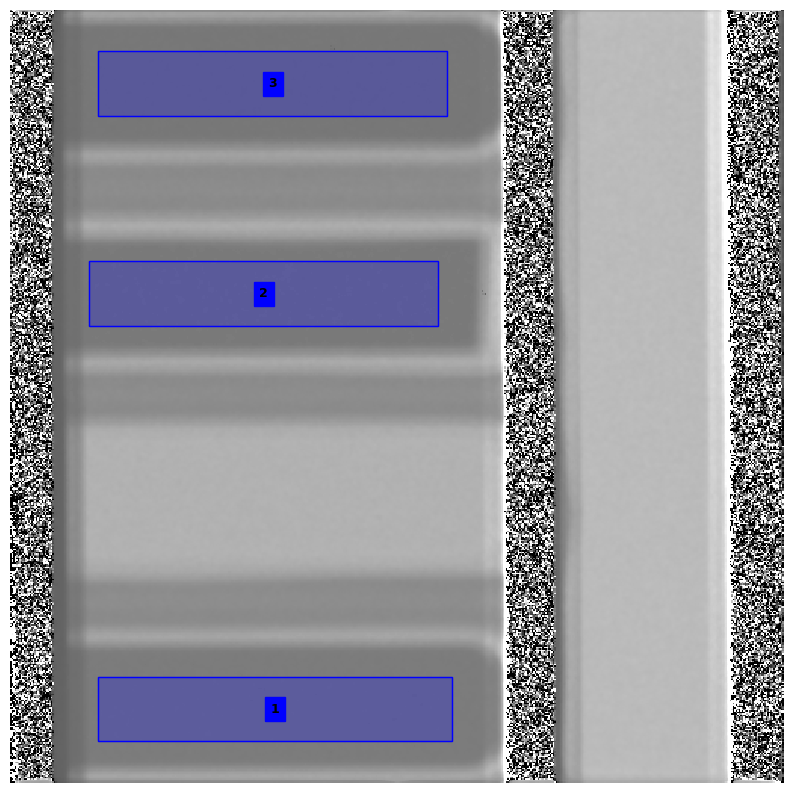

In [17]:
show_img(avg_imgs[0], dr = [(ROIs_003_temp_00_m23_batch03, 'blue')], cmap='gray')

#### Create a dictionary of the ROIs

In [18]:
rois_dict = {}
for name in stack_dict.keys():
    rois_name = 'ROIs_'+ name
    for rois in [rois_name]:
        rois_dict[rois] = eval(rois)

### Extract the values

In [19]:
val_rois = get_roi_values (stack_dict, rois_dict, spectra_file, save_path = dst_dir, binning = 1, 
                                 flight_path = flight_path, start_slice = 0, end_slice='', name_xlsx = 'Roi_values_auto.xlsx', 
                                 save_results = False)

In [20]:
#val_rois = table_val_rois.loc[3:76, :]
#val_rois = table_val_rois.reset_index(drop=True)

val_rois

,Wavelength [Å],Values_003_temp_00_m23_batch03_roi_1,Values_003_temp_00_m23_batch03_roi_2,Values_003_temp_00_m23_batch03_roi_3
0,0.072588,0.287297,0.284541,0.240400
1,0.130658,0.287077,0.287071,0.245343
2,0.188728,0.295628,0.290357,0.251637
3,0.246798,0.299960,0.293596,0.249731
4,0.304869,0.296672,0.290730,0.247874
5,0.362939,0.300279,0.290858,0.253324
6,0.421009,0.304236,0.292061,0.254077
7,0.479079,0.307407,0.291452,0.250319
8,0.537150,0.307837,0.292158,0.252762
9,0.595220,0.306898,0.290714,0.248032


### Remove the casing


In [21]:
trans_rois = divide_DF (val_rois, val_casing)

In [22]:
trans_rois

,Wavelength [Å],Values_003_temp_00_m23_batch03_roi_1,Values_003_temp_00_m23_batch03_roi_2,Values_003_temp_00_m23_batch03_roi_3
0,0.072588,0.320290,0.317218,0.268008
1,0.130658,0.322178,0.322171,0.275342
2,0.188728,0.331314,0.325406,0.282012
3,0.246798,0.337864,0.330697,0.281289
4,0.304869,0.335442,0.328724,0.280267
5,0.362939,0.336708,0.326144,0.284056
6,0.421009,0.343335,0.329596,0.286730
7,0.479079,0.348357,0.330277,0.283665
8,0.537150,0.347104,0.329425,0.285004
9,0.595220,0.346430,0.328162,0.279982


### H cross section parameters

In [ ]:
thickness = 0.3
h2o = {'abbv': 'H2O','composition' : {'H':2.0, 'O':1.0},'density':0.997, 'thickness': thickness}
ec = {'abbv': 'EC', 'composition' : {'C':3.0, 'H':4.0, 'O':3.0},'density':1.32, 'thickness': thickness}
dmc = {'abbv': 'DMC','composition' : {'C':3.0, 'H':6.0, 'O':3.0}, 'density':1.07, 'thickness': thickness}
dec = {'abbv': 'DEC','composition' : {'C':5.0, 'H':10.0, 'O':3.0}, 'density':0.975, 'thickness': thickness}
lipf6 = {'abbv': 'LiPF6','composition' : {'LI':1.0, 'P':1.0, 'F':6.0}, 'density':1.5, 'thickness': thickness}
ec_dmc_11v = {'abbv': 'EC_DMC (1:1v)','molecules' : [ec,0.5,dmc,0.5], 'density':1.28, 'thickness': thickness}
ec_dmc_11w = {'abbv': 'EC_DMC (1:1w)','molecules' : [ec,0.447511501,dmc,0.552488499], 'density':1.2335, 'thickness': thickness}
ec_dec_11v = {'abbv': 'EC_DEC (1:1v)','molecules' : [ec,0.5,dec,0.5], 'density':1.1785, 'thickness': thickness}
#ec_dec_37w = {'abbv': 'EC_DEC (3:7w)','molecules' : [ec,0.240305619,dec,0.759694381], 'density':1.0705, 'thickness': thickness}
lp30 = {'abbv': 'LP30','molecules' : [ec, 0.406359477,dmc, 0.501683056, lipf6, 0.091957467], 'density':1.2795, 'thickness': thickness}
lp40 = {'abbv': 'LP40','molecules' : [ec, 0.447925137,dec, 0.447925137, lipf6, 0.104149725], 'density':1.2635, 'thickness': thickness}
lp47 = {'abbv': 'LP47','molecules' : [ec, 0.218207723,dec, 0.689834809, lipf6 ,0.091957467], 'density':1.1685, 'thickness': thickness}
#ec_dec_sol = {'abbv': 'EC_DEC (sol)','molecules' : [ec,0.5,dec,0.5], 'density':1.1785, 'thickness': thickness}
pe = {'abbv': 'PE', 'composition' : {'C':1.0, 'H':2.0},'density':0.92, 'thickness': 0.215}

## exp1000 -> LP30


In [ ]:
compounds_dict = [dec, pe, h2o]

### Get the cross sections
Function to get the cross sections, the requested_cs is a list of the desired cross-sections options are ['total_cs','h_cs','li_cs']

In [ ]:
requested_cs = ['total_cs']
cs_table = get_cross_sections (trans_rois, compounds_dict, requested_cs, dst_dir = dst_dir, save_table = False, 
                               name_xlsx = 'test.xlsx')

In [ ]:
cs_table

In [ ]:
cs_ref_dir = r"J:\700 Campaigns - internal\2022\PSI22_04NI"
cs_ref_data = pd.read_csv (cs_ref_dir + '\cs_ref_IMAT20.txt',sep='\t')
cs_ref_data = cs_ref_data.loc[0:93, ['orig wvl','orig cs LP30', 'orig cs PE']]
cs_ref_data = cs_ref_data.reset_index(drop=True)
cs_ref_data

In [ ]:
plt.rcParams["figure.figsize"] = [10.0, 7.0]
plt.rcParams["figure.autolayout"] = True

ax = cs_table.plot.scatter(x='Wavelength [Å]', y=['CS_tot_PE_Values_019_temp_04_m23_batch03_roi_2'])
cs_ref_data.plot(ax = ax, x='orig wvl', y=['orig cs PE'], 
                 grid = True, fontsize = 12, kind = 'scatter', color = 'r')

plt.suptitle('H CS in BOA experiments', fontsize=15)
ax.set_xlabel("Wavelength [A]")
ax.set_ylabel("H cross-section [barns]")
ax.legend(fontsize=12)
ax.xaxis.label.set_size(15)
ax.yaxis.label.set_size(15)
plt.show()

## Option to make the relative attenuation images 


In [ ]:
HE_n_LE = ([15,30],[70,85])

trans_imgs_dict = read_saved_dict (src_dir, proc_folder = [])

In [ ]:
proc_folder1 = [key for key in trans_imgs_dict.keys() if 'batch01' in key]
proc_folder2 = [key for key in trans_imgs_dict.keys() if 'batch02' in key]
proc_folder3 = [key for key in trans_imgs_dict.keys() if 'batch03' in key]

In [ ]:
res_stack = get_relative_att_stack (trans_imgs_dict, dst_dir, HE_n_LE, proc_folder = proc_folder1, save=False)